# 04 Análise de Qualidade e Acurácia Posicional

**Objetivo:** Avaliar a integração focando nos pares com alta certeza metodológica (MCI >= 0.8). Vamos mensurar a distância física real (erro posicional - RMSE) entre o dado do IBGE e o Gold Standard da Prefeitura (BHMap). Também avaliaremos a consistência dos atributos.

**Entrada:**
- `data/interim/cnefe_match_bhmap.parquet`


In [1]:
import sys
import os
from pathlib import Path

os.chdir('..')
sys.path.append(os.getcwd())

%load_ext autoreload
%autoreload 2

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.metrics import calculate_positional_rmse, generate_quality_summary


## 1. Carregamento e Filtragem por Alta Certeza (MCI >= 0.8)

In [2]:
print("Lendo os dados...")
gdf_matched = gpd.read_parquet(config.INTERIM_DATA_DIR / "cnefe_match_bhmap.parquet")

# Resumo Estatístico
quality_summary = generate_quality_summary(gdf_matched, mci_threshold=0.8)
for k, v in quality_summary.items():
    print(f"{k}: {v}")

high_certainty_df = gdf_matched[gdf_matched['MCI'] >= 0.8].copy()


Lendo os dados...


total_records: 1180102
high_certainty_matches: 941181
high_certainty_percent: 79.75
average_positional_error_m: 6.86
positional_rmse_m: 9.04


## 2. Acurácia Posicional (Root Mean Square Error)
O CNEFE capta as coordenadas da face da quadra ou da rota do pesquisador, enquanto o BHMap é vetorizado sobre telhados ou eixos precisos. O quão distantes eles estão quando a string do endereço descreve perfeitamente o mesmo local físico?

RMSE Posicional Global (MCI >= 0.8): 9.04 metros


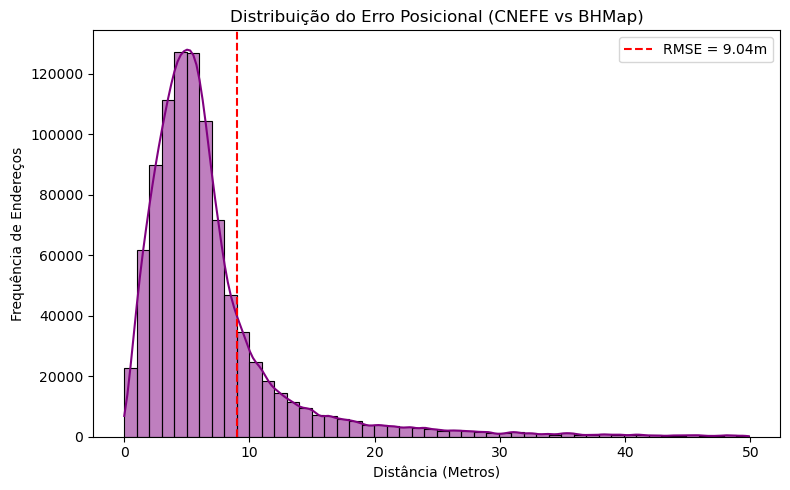

In [3]:
rmse_pos = calculate_positional_rmse(high_certainty_df, 'spatial_distance')
print(f"RMSE Posicional Global (MCI >= 0.8): {rmse_pos} metros")

# Distribuição do Erro (Limitando visivelmente a 50m pelo buffer)
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(high_certainty_df['spatial_distance'], bins=50, kde=True, color='purple', ax=ax)
ax.axvline(x=rmse_pos, color='red', linestyle='--', label=f'RMSE = {rmse_pos}m')
ax.set_title("Distribuição do Erro Posicional (CNEFE vs BHMap)")
ax.set_xlabel("Distância (Metros)")
ax.set_ylabel("Frequência de Endereços")
ax.legend()
sns_despine = getattr(plt, 'despine', lambda: None)
sns_despine()
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "04_positional_error_distribution.png", dpi=300)


## 3. Consistência Semântica (Tipo de Logradouro)
Quantas vezes um "Beco" no IBGE é cadastrado como "Rua" na Prefeitura? Analisamos a consistência topológica das descrições do logradouro para os registros de alta certeza.

In [4]:
# Tentativa de extrair o tipo do logradouro do CNEFE (que vem concatenado string inteira)
# Vamos comparar as palavras iniciais se possível, ou ver se os tipos oficiais do BHMap estão batendo
# Extract first word from CNEFE string
high_certainty_df['cnefe_tipo_estimado'] = high_certainty_df['std_logradouro_completo'].astype(str).str.split().str[0]

# Comparar cruzamento cruzado (apenas os 10 mais frenquentes do BHMap)
top_types_bhmap = high_certainty_df['std_tipo_logradouro'].value_counts().nlargest(10).index
subset = high_certainty_df[high_certainty_df['std_tipo_logradouro'].isin(top_types_bhmap)]

# Uma matriz de contingência simples
contingency = pd.crosstab(subset['cnefe_tipo_estimado'], subset['std_tipo_logradouro'])
display(contingency.head(10))


std_tipo_logradouro,ALA,AVE,BEC,LRG,PCA,ROD,RUA,TRV,VDP,VIA
cnefe_tipo_estimado,,,,,,,,,,
ACESSO,0,0,0,0,0,3,2,0,0,0
ALAMEDA,1065,0,33,0,0,0,114,0,0,0
ANEL,0,0,0,0,0,44,0,0,0,0
AVENIDA,0,37102,12,0,0,0,2,0,0,0
BECO,0,0,14198,0,0,0,15,0,0,0
BEIRA,0,0,0,0,0,0,1,0,0,0
ESTRADA,0,0,0,0,0,0,36,0,0,0
FINAL,0,0,0,0,0,0,8,0,0,0
LARGO,0,0,0,22,0,0,0,0,0,0
